## Masked Autoencoders: Visualization Demo

This is a visualization demo using our pre-trained MAE models. No GPU is needed.

### Creazione dataset 9 canali

In [1]:
#!pip uninstall timm -y
!pip install timm


In [1]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
from astropy.io import fits
import warnings
warnings.filterwarnings("ignore")
import os
import numpy as npmenom
import matplotlib.pyplot as plt
import sunpy
from sunpy.map import Map
import sys
import os
import requests
import torch.nn as nn
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
from PIL import Image
from torch import optim 
#from utils import validate_one_epoch, run_one_image, show_image

from torch.utils.data import DataLoader


torch.manual_seed(1)
from functools import partial
from mae.models_mae_2 import mae_model_channel_masking_9ch_with_temporal_attn
from mae import models_mae_2
from  torchvision.transforms import transforms


from mae.MAE import new_mae_trial_small_patches
from dataset import SDOMosaicZarrDataset, SDO_Dataset_channels

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

from dataset import SDOMosaicZarrDataset, SDO_Dataset_channels, SDO_Dataset_channels_FAST
import random
random.seed(1)

all_years = list(range(2011, 2026))
random.shuffle(all_years)

# Divisione in 60% train, 20% validation, 20% test
train_split = int(0.6 * len(all_years))
val_split = int(0.8 * len(all_years))

train_years = sorted(all_years[:train_split])
val_years = sorted(all_years[train_split:val_split])

test_years = sorted(all_years[val_split:])
image_size = 1024

zarr_path = "/home/gpatane/Dataset/zarr_file_magnetogram_1024_definitivo.zarr"

wavelengths = ['1700A', '1600A', '335A', '304A', '211A', '193A', '171A', '131A', 'Magnetogram']
#['1700A', '1600A', '335A', '304A', '211A', '193A', '171A', '131A', '94A', 'Ic_noLimbDark', 'Magnetogram']


train_dataset = SDO_Dataset_channels_FAST(zarr_path, train_years, wavelengths, target_size=image_size)
validation_dataset = SDO_Dataset_channels_FAST(zarr_path, val_years, wavelengths, target_size=image_size)
test_dataset = SDO_Dataset_channels_FAST(zarr_path, test_years, wavelengths, target_size=image_size)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=4)
val_loader = DataLoader(validation_dataset, batch_size=4, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True, num_workers=4)


## Carico modello a 9 canali


In [ ]:
import wandb
import os
from tqdm import tqdm
from mae.models_mae_2 import MaskedAutoencoderViT, mae_model_channel_masking_9ch_with_temporal_attn


    
    
model = mae_model_channel_masking_9ch_with_temporal_attn(
    img_size=1024,
    patch_size=16,
    in_chans=9,
).to(device)
checkpoint_path = '/home/gpatane/SDO_downstream/mae_project/checkpoints/checkpoint_epoch55.pth'
#checkpoint_path = '/home/gpatane/SDO_downstream/mae_project/checkpoints/best_model.pth'
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])


In [9]:
def visualize_channel_masking_reconstruction(model, data_loader, device, wavelengths, mask_channels = None):
    """
    Visualizza la ricostruzione con mascheramento dei canali.
    
    Per il mascheramento dei canali, dobbiamo intercettare l'input mascherato
    prima che venga processato dal modello.
    """
    model.eval()
    
    with torch.no_grad():
        # Prendi un batch
        batch = next(iter(data_loader))
        batch_original = batch.clone()
        batch = batch.to(device)
        
        # Determina quanti canali mascherare
        n_img_mask = mask_channels if mask_channels is not None else model.n_img_mask if model.n_img_mask is not None else random.randint(1, model.in_chans - 1)
        # Seleziona casualmente i canali da mascherare
        channel_indices = random.sample(range(model.in_chans), n_img_mask)
        print(f"Canali mascherati: {[wavelengths[i] for i in channel_indices]}")
        
        # Crea input mascherato manualmente (come fa il modello)
        batch_masked = batch.clone()
        for ch_idx in channel_indices:
            batch_masked[:, ch_idx, :, :] = 0
        
        # Forward pass con l'input già mascherato
        # Per fare questo dobbiamo modificare temporaneamente il modello
        # oppure passare attraverso il forward_encoder direttamente
        
        # Opzione: fare forward pass completo e ricostruire
        loss, pred, mask = model(batch)
        reconstructed = model.unpatchify(pred)
        
        # Visualizza
        B, C, H, W = batch.shape
        
        fig, axes = plt.subplots(3, C, figsize=(C*3, 10))
        
        for c in range(C):
            # Riga 1: Originale
            ax = axes[0, c]
            img_original = batch[0, c].cpu().numpy()
            
            if wavelengths[c] == 'Magnetogram':
                cmap = 'gray'
            else:
                cmap = 'sdoaia' + wavelengths[c].replace('A', '')
            
            vmin, vmax = np.percentile(img_original, [2.5, 99.5])
            ax.imshow(img_original, cmap=cmap, vmin=vmin, vmax=vmax)
            
            title_color = 'red' if c in channel_indices else 'black'
            ax.set_title(f'{wavelengths[c]}\n{"MASKED" if c in channel_indices else "visible"}', 
                        fontsize=11, color=title_color, fontweight='bold' if c in channel_indices else 'normal')
            ax.axis('off')
            
            if c in channel_indices:
                # Aggiungi un bordo rosso per i canali mascherati
                for spine in ax.spines.values():
                    spine.set_edgecolor('red')
                    spine.set_linewidth(3)
                    spine.set_visible(True)
            
            # Riga 2: Input (con canali mascherati a zero)
            ax = axes[1, c]
            if c in channel_indices:
                # Mostra nero per canali mascherati
                ax.imshow(np.zeros_like(img_original), cmap='gray', vmin=0, vmax=1)
                ax.set_title('Input: ZERO', fontsize=10, color='red')
            else:
                ax.imshow(img_original, cmap=cmap, vmin=vmin, vmax=vmax)
                ax.set_title('Input: original', fontsize=10)
            ax.axis('off')
            
            # Riga 3: Ricostruito
            ax = axes[2, c]
            img_recon = reconstructed[0, c].cpu().numpy()
            vmin_r, vmax_r = np.percentile(img_recon, [2.5, 99.5])
            
            if c in channel_indices:
                ax.imshow(img_recon, cmap=cmap, vmin=vmin_r, vmax=vmax_r)
                ax.set_title('RECONSTRUCTED!', fontsize=10, color='green', fontweight='bold')
            else:
                ax.imshow(img_original, cmap=cmap, vmin=vmin, vmax=vmax)
                ax.set_title('Original', fontsize=10)
            ax.axis('off')
        
        axes[0, 0].text(-0.1, 0.5, 'Original', transform=axes[0, 0].transAxes, 
                       rotation=90, va='center', ha='right', fontsize=14, fontweight='bold')
        axes[1, 0].text(-0.1, 0.5, 'Model Input', transform=axes[1, 0].transAxes, 
                       rotation=90, va='center', ha='right', fontsize=14, fontweight='bold')
        axes[2, 0].text(-0.1, 0.5, 'Reconstructed', transform=axes[2, 0].transAxes, 
                       rotation=90, va='center', ha='right', fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        fig.suptitle(f'Channel Masking Reconstruction (Loss: {loss.item():.4f})', 
                    fontsize=16, y=1.01)
        plt.show()
        
        return loss, reconstructed, channel_indices

# Usa la funzione
# print("🎨 Visualizzazione ricostruzione con mascheramento canali:")
# loss, recon, masked_channels = visualize_channel_masking_reconstruction(
#     model, test_loader, device, wavelengths, mask_channels=3
# )

## Testing

In [3]:
from utils import validate_one_epoch
avg_epoch_loss, avg_epoch_ssim = validate_one_epoch(model, test_loader, device)
print(f' average loss: {avg_epoch_loss:.4f}, average ssim: {avg_epoch_ssim:.4f} ')

 average loss: 0.0770, average ssim: 0.8370 


🎨 Visualizzazione ricostruzione con mascheramento canali:
Canali mascherati: ['1700A', '131A', 'Magnetogram', '335A', '211A', '304A', '193A', '171A']


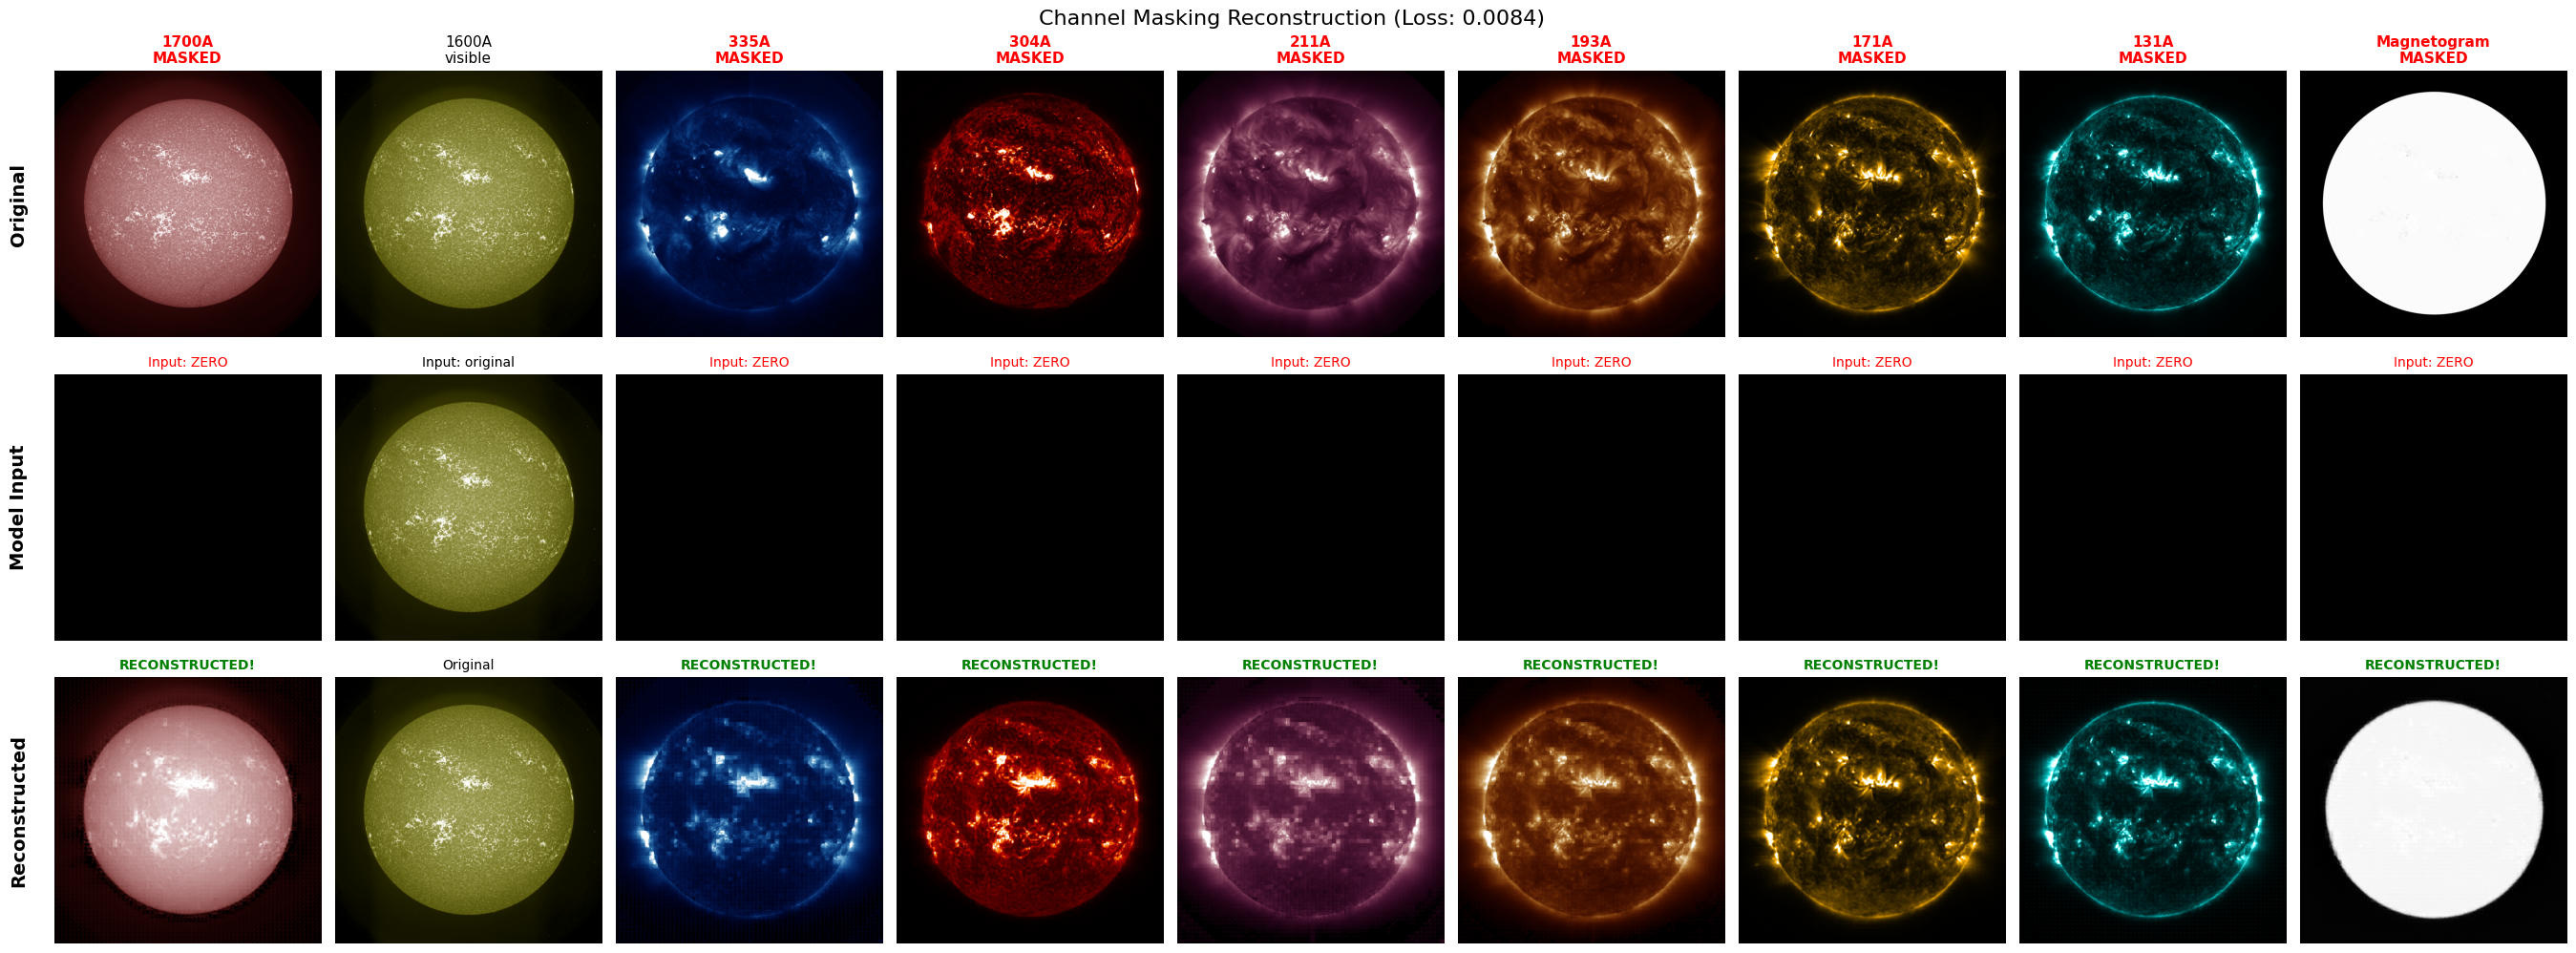

In [13]:
from mae.models_mae_2 import mae_model_fixed_channel_masking
model = mae_model_fixed_channel_masking(
    img_size=1024,
    patch_size=16,
    in_chans=9,
    n_channels_to_mask=8
).to(device)
checkpoint_path = '/home/gpatane/SDO_downstream/mae_project/checkpoints/checkpoint_epoch55.pth'
#checkpoint_path = '/home/gpatane/SDO_downstream/mae_project/checkpoints/best_model.pth'
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])

from utils import validate_one_epoch
print("🎨 Visualizzazione ricostruzione con mascheramento canali:")
loss, recon, masked_channels = visualize_channel_masking_reconstruction(
    model, test_loader, device, wavelengths, mask_channels=8
)


masking 4 images: average loss: 0.0750, average ssim: 0.8472